In [41]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CIFAR100
from pathlib import Path
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

In [42]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [43]:
train_transform = transforms.Compose([transforms.Resize((32,32)), transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(15),
                               transforms.RandomCrop(32,padding=4,padding_mode='reflect'),transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((32,32)), transforms.ToTensor()])

In [ ]:
train_data = CIFAR100(root='data', train=True, download=True, transform=train_transform)
test_data = CIFAR100(root='data', train=False, download=True, transform=test_transform)

In [45]:
train_data.classes

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [46]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)

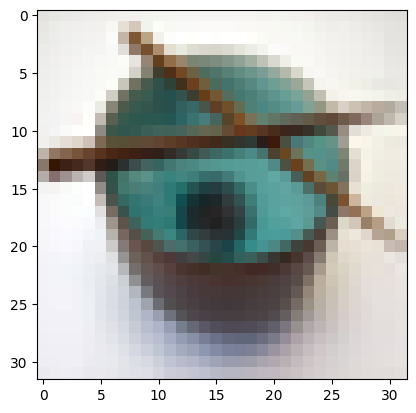

In [47]:
img, label = train_data[random.randint(0,len(train_data))]
plt.imshow(img.permute(1,2,0))

In [48]:
class CifarModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(nn.Conv2d(3,32,kernel_size=3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.Conv2d(32,32,kernel_size=3,padding=1), 
                                    nn.BatchNorm2d(32),nn.ReLU(), nn.Dropout(p=0.25),nn.MaxPool2d(kernel_size=2))
        self.layer2 = nn.Sequential(nn.Conv2d(32,64,kernel_size=3,padding=1), nn.BatchNorm2d(64),nn.ReLU(), nn.Conv2d(64,64,kernel_size=3,padding=1), 
                                    nn.BatchNorm2d(64),nn.ReLU(), nn.Dropout(p=0.25),nn.MaxPool2d(kernel_size=2))
        self.layer3 = nn.Sequential(nn.Flatten(), nn.Dropout(p=0.5), nn.Linear(64*8*8, 512), nn.BatchNorm1d(512),
                                    nn.ReLU(), nn.Linear(512,100))
    def forward(self, x):
        x1 = self.layer1(x)
        x2 = self.layer2(x1)
        return self.layer3(x2)
model = CifarModel().to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [ ]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=20,gamma=0.2)

In [51]:
def acc_fn(pred,y):
    pred = pred.argmax(dim=1)
    acc = torch.eq(pred,y).sum().item()/len(pred)
    return acc*100

In [52]:
def train_step(model,dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,device=device):
    model.train()
    acc = 0
    floss = 0
    for X,y in dataloader:
        X,y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = loss_fn(logits,y)
        loss.backward()
        optimizer.step()
        acc += acc_fn(logits, y)
        floss +=loss.item()
    return floss / len(dataloader), acc / len(dataloader)

def test_step(model,dataloader=test_dataloader,loss_fn=loss_fn, device=device):
    model.eval()
    acc = 0
    floss = 0
    with torch.inference_mode():
        for X,y in dataloader:
            X,y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits,y)
            acc += acc_fn(logits, y)
            floss += loss.item()
        return floss / len(dataloader), acc / len(dataloader)



In [53]:
for epoch in range(51):
    train_loss, train_acc = train_step(model)
    test_loss, test_acc = test_step(model)
    scheduler.step()
    print(f'Epoch {epoch}\nTrain loss: {train_loss} Test loss: {test_loss}\nTrain acc:{train_acc} Test acc: {test_acc}')

Epoch 0
Train loss: 3.1786070430576228 Test loss: 2.968028792938866
Train acc:22.596769033909148 Test acc: 26.886980830670925
Epoch 1
Train loss: 2.439794563286135 Test loss: 2.4786928964499086
Train acc:36.970169545745364 Test acc: 36.97084664536741
Epoch 2
Train loss: 2.1496218656471577 Test loss: 2.2978134901759724
Train acc:43.136196417146515 Test acc: 40.42531948881789
Epoch 3
Train loss: 1.9730048201744632 Test loss: 2.079463922558501
Train acc:47.27287268074216 Test acc: 46.11621405750799
Epoch 4
Train loss: 1.8339963582411685 Test loss: 2.0064489948102078
Train acc:50.44585732565579 Test acc: 46.96485623003195
Epoch 5
Train loss: 1.7193135939876925 Test loss: 1.9665900556424174
Train acc:52.95505438259757 Test acc: 48.42252396166134
Epoch 6
Train loss: 1.621814554231867 Test loss: 1.891157173501036
Train acc:54.95241522712732 Test acc: 50.039936102236425
Epoch 7
Train loss: 1.539719095461962 Test loss: 1.908731869615305
Train acc:57.031749840051184 Test acc: 49.790335463258785


KeyboardInterrupt: 

In [ ]:
print(len(train_dataloader), len(test_dataloader))

1563 313
